In [1]:
import pandas as pd 
import seaborn as sns 
import plotly.express as px 
from sklearn.preprocessing import LabelEncoder
import numpy as np

In [2]:
df = pd.read_csv('datasets/preprocessed_dataset.csv')

In [3]:
df.head()

,order_id,order_status,customer_id,product_id,price,freight_value,product_name,product_name_length,product_description_length,product_photos_qty,customer_city,estimated_delivery_date,actual_delivery_date,review_score,is_delayed
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,9ef432eb6251297304e76186b10a928d,87285b34884572647811a353c7ac498a,29.99,8.72,housewares,40.0,268.0,4.0,sao paulo,2017-10-18,2017-10-10 21:25:13,4,False
1,53cdb2fc8bc7dce0b6741e2150273451,delivered,b0830fb4747a6c6d20dea0b8c802d7ef,595fac2a385ac33a80bd5114aec74eb8,118.70,22.76,perfumery,29.0,178.0,1.0,barreiras,2018-08-13,2018-08-07 15:27:45,4,False
2,47770eb9100c2d0c44946d9cf07ec65d,delivered,41ce2a54c0b03bf3443c3d931a367089,aa4383b373c6aca5d8797843e5594415,159.90,19.22,auto,46.0,232.0,1.0,vianopolis,2018-09-04,2018-08-17 18:06:29,5,False
3,949d5b44dbf5de918fe9c16f97b45f8a,delivered,f88197465ea7920adcdbec7375364d82,d0b61bfb1de832b15ba9d266ca96e5b0,45.00,27.20,pet_shop,59.0,468.0,3.0,sao goncalo do amarante,2017-12-15,2017-12-02 00:28:42,5,False
4,ad21c59c0840e6cb83a9ceb5573f8159,delivered,8ab97904e6daea8866dbdbc4fb7aad2c,65266b2da20d04dbe00c5c2d3bb7859e,19.90,8.72,stationery,38.0,316.0,4.0,santo andre,2018-02-26,2018-02-16 18:17:02,5,False


In [4]:
encoder = LabelEncoder()
df['encoded_is_delayed'] = encoder.fit_transform(df['is_delayed'])

df = df.drop(columns = ['is_delayed'])

<Axes: >

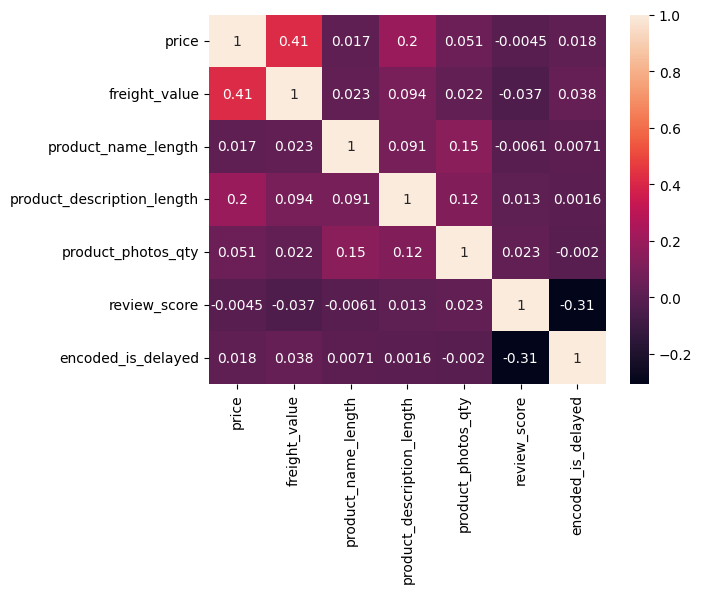

In [5]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

<Axes: xlabel='freight_value', ylabel='price'>

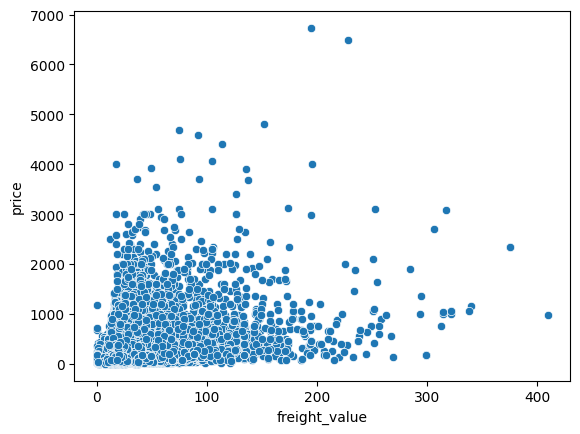

In [6]:
sns.scatterplot(data = df, x = 'freight_value',y='price')

In [7]:
df['log_price'] = np.log1p(df['price'])
df['log_freight_value'] = np.log1p(df['freight_value'])

<Axes: xlabel='log_price', ylabel='log_freight_value'>

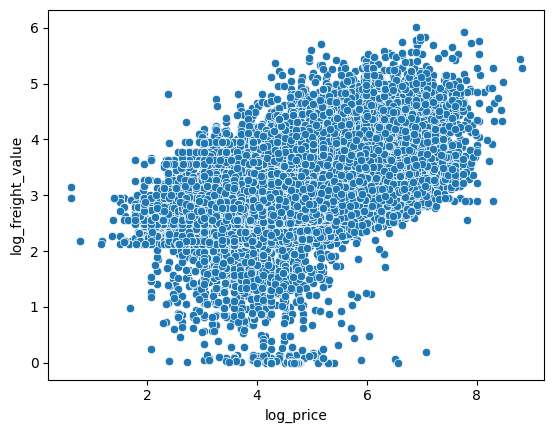

In [8]:
sns.scatterplot(
    df,
    x = 'log_price',
    y = 'log_freight_value',
)

<Axes: xlabel='review_score', ylabel='encoded_is_delayed'>

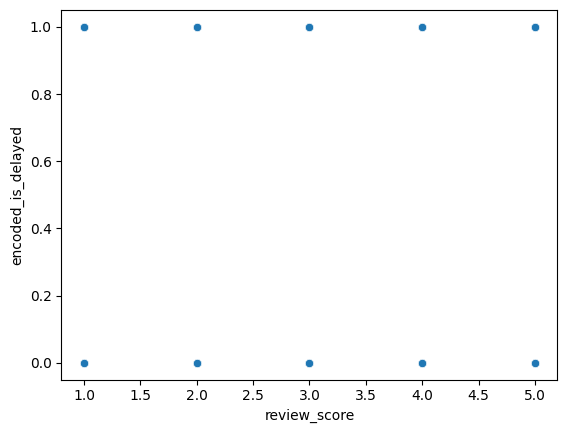

In [9]:
sns.scatterplot(
    df,
    y = 'encoded_is_delayed',
    x = 'review_score',
)

<Axes: xlabel='encoded_is_delayed', ylabel='review_score'>

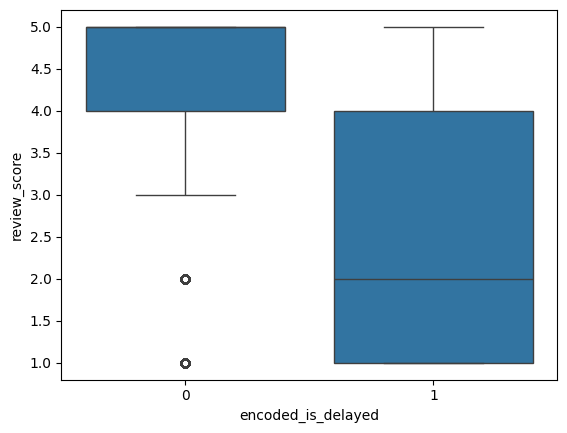

In [10]:
sns.boxplot(x='encoded_is_delayed', y='review_score', data=df)

In [11]:
from scipy.stats import mannwhitneyu

not_delayed = df[df['encoded_is_delayed'] == 0]['review_score']
delayed     = df[df['encoded_is_delayed'] == 1]['review_score']

stat, p = mannwhitneyu(not_delayed, delayed, alternative='greater')

print(f"U statistic: {stat}")
print(f"P-value: {p}")

if p < 0.05:
    print("Significant: non-delayed orders have higher ratings")
else:
    print("No significant difference found")

U statistic: 651450787.0
P-value: 0.0
Significant: non-delayed orders have higher ratings


In [12]:
df['actual_delivery_date'] = pd.to_datetime(df['actual_delivery_date'],errors = 'coerce')
df['estimated_delivery_date'] = pd.to_datetime(df['estimated_delivery_date'], errors = 'coerce')
df['delay_days'] = df['actual_delivery_date'] - df['estimated_delivery_date']